Max imaginary part (should be ~0): 8.498318493366241e-08
omega= 0.000  DFT approx= 2.00002  analytical= 2.00000  error= 1.60e-05
omega= 0.942  DFT approx= 1.05919  analytical= 1.05917  error= 1.60e-05
omega= 2.985  DFT approx= 0.20189  analytical= 0.20187  error= 1.59e-05
omega=10.053  DFT approx= 0.01961  analytical= 0.01960  error= 1.59e-05


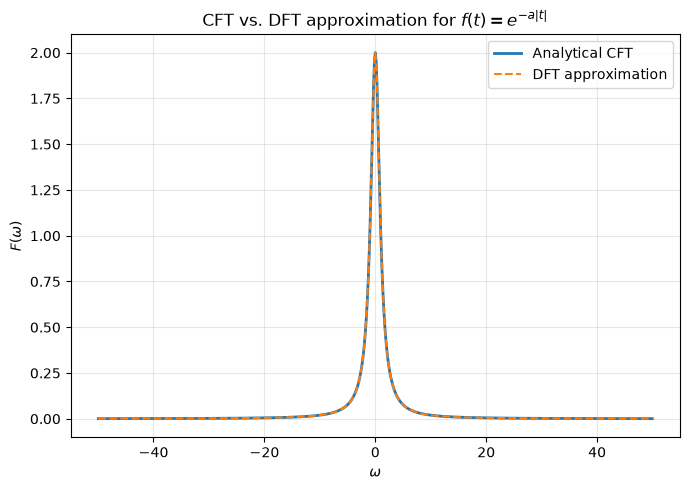

In [ ]:
"""
Compare the DFT (via JAX's FFT) of f(t) = exp(-a|t|), sampled finely,
against the known analytical CFT: F(omega) = 2a / (a^2 + omega^2).

Key idea:
    F(omega) ~= dt * sum_n x(t_n) exp(-i * omega * t_n)

jnp.fft.fft assumes samples start at t=0 (n=0 -> t=0). Since we sample
symmetrically around t=0 (to capture the decay on both sides), we use
ifftshift on the *input* array to move the t=0 sample to index 0 before
calling fft. This avoids having to manually apply a phase-correction
factor for the time offset.
"""

import jax.numpy as jnp
import matplotlib.pyplot as plt


def f(t, a):
    """The function we're transforming: exp(-a|t|)."""
    return jnp.exp(-a * jnp.abs(t))


def F_analytical(omega, a):
    """Known closed-form CFT: 2a / (a^2 + omega^2)."""
    return 2 * a / (a**2 + omega**2)


def dft_approx(a, T=40.0, N=4096):
    """
    Approximate the CFT of f(t)=exp(-a|t|) using a finely-sampled DFT.

    T : total time window (samples cover [-T/2, T/2))
    N : number of samples (larger N -> finer dt -> less aliasing,
        larger T -> better frequency resolution / less truncation error)
    """
    dt = T / N

    # Sample times centered at 0: ..., -dt, 0, dt, 2dt, ...
    t = jnp.arange(N) * dt - T / 2
    x = f(t, a)

    # Move the t=0 sample to index 0 so jnp.fft.fft's implicit
    # "n=0 corresponds to t=0" assumption holds, then shift the
    # output back into natural (negative-to-positive) frequency order.
    X = jnp.fft.fft(jnp.fft.ifftshift(x))
    X = jnp.fft.fftshift(X)

    freq_arr_first_half = jnp.arange(0.5*N)/(N*dt)
    freq_arr_second_half = jnp.arange(-0.5*N, 0)/(N*dt)
    freq_arr = jnp.concat((freq_arr_first_half, freq_arr_second_half))
    omega = jnp.fft.fftshift(freq_arr) * 2 * jnp.pi
    F_approx = dt * X

    return omega, F_approx


if __name__ == "__main__":
    a = 1.0
    omega, F_approx = dft_approx(a, T=40.0, N=4096)

    F_true = F_analytical(omega, a)

    # F_approx should be (very nearly) real, since f(t) is real and even
    print("Max imaginary part (should be ~0):",
          float(jnp.max(jnp.abs(F_approx.imag))))

    # Spot-check a few frequencies
    for w_check in [0.0, 1.0, 3.0, 10.0]:
        idx = int(jnp.argmin(jnp.abs(omega - w_check)))
        approx_val = float(F_approx[idx].real)
        true_val = float(F_analytical(omega[idx], a))
        print(f"omega={float(omega[idx]):6.3f}  "
              f"DFT approx={approx_val:8.5f}  "
              f"analytical={true_val:8.5f}  "
              f"error={approx_val - true_val: .2e}")

    # Plot comparison
    fig, ax = plt.subplots(figsize=(7, 5))
    window = jnp.abs(omega) <= 50  # zoom in near the interesting region
    ax.plot(omega[window], F_true[window], label="Analytical CFT", lw=2)
    ax.plot(omega[window], F_approx.real[window], "--",
             label="DFT approximation", lw=1.5)
    ax.set_xlabel(r"$\omega$")
    ax.set_ylabel(r"$F(\omega)$")
    ax.set_title(r"CFT vs. DFT approximation for $f(t)=e^{-a|t|}$")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()